# 1.7 2D Axisymmetric Borehole Simulation

This notebook is a focused starting point for developing 2D borehole simulations. It uses an axisymmetric radial-depth model: the horizontal coordinate is radius $r$, the vertical coordinate is depth $z$, and the line `x_min`/`r = 0` is the cylindrical symmetry axis.

The example is intentionally small and inspectable. It combines an acoustic borehole fluid, elastic casing/cement, and an elastic formation in a coupled axisymmetric simulation. The borehole radii are enlarged relative to a field-scale cased well so the mesh and ParaView output are easy to inspect in a tutorial-sized run. Once the workflow is validated, reduce the radii and tighten the borehole refinement for the target model.


## What Axisymmetry Changes

A 2D axisymmetric simulation is not a Cartesian $x$-$z$ slice. The model is revolved around the symmetry axis, so a point at radius `r = 0.1 km` represents a ring in 3D. This is useful for borehole and radially symmetric source tests because the model keeps 3D spreading behavior while solving a 2D radial-depth problem.

| Concept | Notebook choice | Practical meaning |
| --- | --- | --- |
| Coordinates | `x` means radius $r$, `z` means depth | Model, source, and receiver coordinates are radial-depth positions. |
| Symmetry axis | `x_min` with `symmetric_r` | Enforces regular non-torsional axisymmetric behavior at $r=0$. |
| Coordinate system | `CoordinateSystem.cylindrical(..., fixed_axis="theta")` | Records that the omitted coordinate is the azimuthal angle. |
| Physics | `physics="coupled", axisymmetric=True` | Normalizes to coupled axisymmetric solver physics so acoustic and elastic subdomains can be combined. |
| Borehole parts | `model.add_borehole(..., x=0, parts=[...])` | Radial material parts are centered on the symmetry axis. |


## Imports

The notebook uses the standard public API style, plus `Image/display` so screenshots remain visible after the notebook is reopened.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

import frequensolve as fs

u = fs.ureg


## Build A Borehole-Ready Axisymmetric Model

The layered model provides the formation background. `add_borehole(...)` adds radial parts around the well axis and creates matching material subdomains when `physics` and `properties` are supplied in each part dictionary.

In this notebook the well axis is the symmetry axis, so `x=0`. Each borehole part specifies its outer radius `r`; the first part fills from $r=0$ to its radius, and each later part starts at the previous part radius.


In [2]:
project = fs.Project(
    name="project",
    pretty_name="axisymmetric_borehole",
    path="./scratch/tutorials/axisymmetric_borehole",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="axisymmetric_borehole",
    physics="coupled",
    dimension=2,
    axisymmetric=True,
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)
sim.global_coordinate_system = fs.CoordinateSystem.cylindrical(
    name="global",
    ndim=2,
    fixed_axis="theta",
    fixed_value=0.0,
)

model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 0.5])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="upper_formation",
    mesh_block_id=1,
    physics="elastic:iso",
    properties={
        "Vp": 2.6 * u.km / u.s,
        "Vs": 1.35 * u.km / u.s,
        "Rho": 2.25 * u.g / u.cm**3,
    },
)
model.add_surface(name="interface", depth=0.42 * u.km)
model.add_layer(
    name="lower_formation",
    mesh_block_id=2,
    physics="elastic:iso",
    properties={
        "Vp": 3.2 * u.km / u.s,
        "Vs": 1.8 * u.km / u.s,
        "Rho": 2.45 * u.g / u.cm**3,
    },
)
model.add_surface(name="bottom", depth=0.8 * u.km)

model.add_borehole(
    name="well_1",
    x=0.0 * u.km,
    top="top",
    bottom="bottom",
    parts=[
        {
            "name": "fluid",
            "mesh_block_id": 20,
            "r": 0.020 * u.km,
            "physics": "acoustic",
            "properties": {
                "Vp": 1.50 * u.km / u.s,
                "Rho": 1.02 * u.g / u.cm**3,
            },
        },
        {
            "name": "casing",
            "mesh_block_id": 21,
            "r": 0.026 * u.km,
            "physics": "elastic:iso",
            "properties": {
                "Vp": 5.9 * u.km / u.s,
                "Vs": 3.2 * u.km / u.s,
                "Rho": 7.85 * u.g / u.cm**3,
            },
        },
        {
            "name": "cement",
            "mesh_block_id": 22,
            "r": 0.040 * u.km,
            "physics": "elastic:iso",
            "properties": {
                "Vp": 3.4 * u.km / u.s,
                "Vs": 1.9 * u.km / u.s,
                "Rho": 2.1 * u.g / u.cm**3,
            },
        },
    ],
)

sim += model


## Inspect The Model Before Meshing

The plot is a material-property QC view. Borehole material subdomains are sampled into the model image, so the enlarged borehole region should appear by its own property values near the symmetry axis. In a true field-scale borehole, the casing/fluid/cement radii may be too small to see at this plot scale; use `borehole.draw(...)` for a radial profile and ParaView mesh/field output for zoomed mesh inspection.

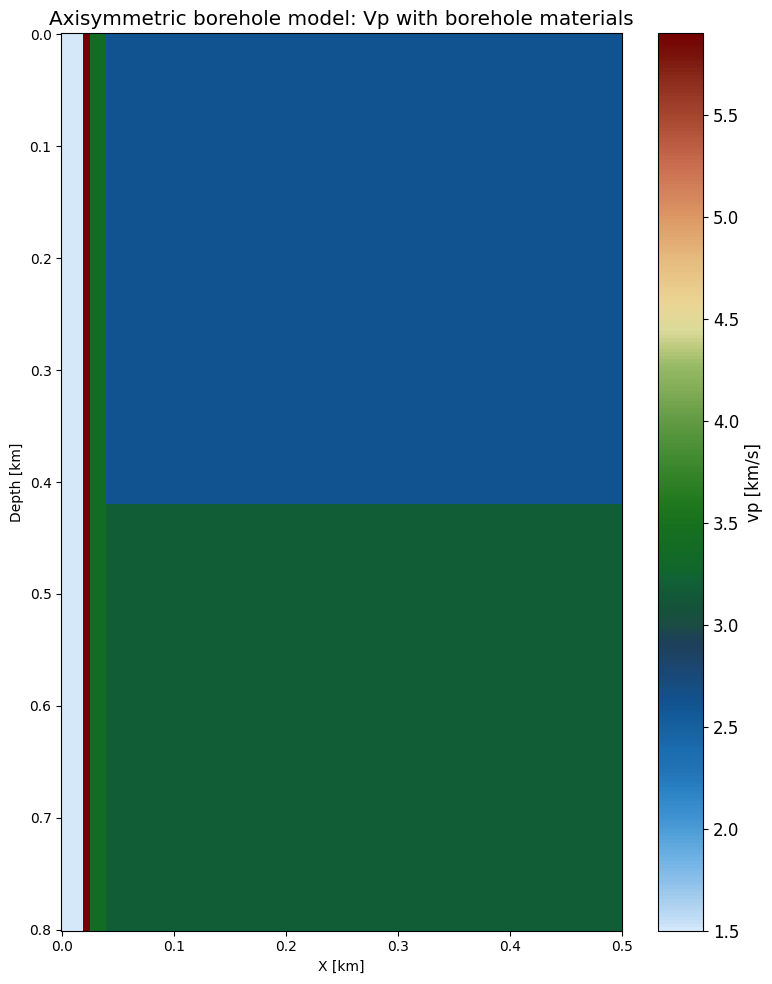

In [3]:
fig, ax = plt.subplots(figsize=(8, 10))
model.plot(
    "vp",
    ax=ax,
    aspect="equal",
    cmap=fs.BuGrOr,
    surfaces=False,
)
ax.set_title("Axisymmetric borehole model: Vp with borehole materials")
fig.tight_layout()


## Mesh Controls And Boundary Conditions

The mesh is generated from the layered model so the borehole geometry remains available to the mesher. `refine_around_borehole(...)` requests smaller elements near the borehole and preserves borehole edges when supported.

Boundary conditions follow the radial-depth interpretation:

| Boundary | Condition | Reason |
| --- | --- | --- |
| `x_min` / $r=0$ | `symmetric_r` | Cylindrical symmetry axis for non-torsional axisymmetric elastic/coupled runs. |
| `z_min` | `free` | Free top surface. |
| `x_max`, `z_max` | `pml` | Absorbing outer radial and bottom boundaries. |

The PML width is frequency dependent and auto-extruded outside the physical model. The `pml_wavelengths` value controls the target width in wavelengths at the simulated frequency.


In [5]:
mesh = model.hex_mesh_generator([14, 18])
mesh.refine_around_borehole(
    "well_1",
    padding=0.08 * u.km,
    max_size=0.006 * u.km,
    max_growth=1.45,
)
sim += mesh
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=10.0, f_high=80.0)
sim.mesh.set_source_grading(d0=0.01 * u.km, d1=0.08 * u.km, mult=2.0)
sim.mesh.set_receiver_grading(d0=0.01 * u.km, d1=0.06 * u.km, mult=2.0)

sim += fs.BoundaryCondition(conditions=["symmetric_r"], boundaries=["x_min"])
sim += fs.BoundaryCondition(conditions=["free"], boundaries=["z_min"])
sim += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_max", "z_max"],
    pml_wavelengths=1.0,
    pml_exponent=3.0,
    pml_reflection=1.0e-3,
)


## Sources And Receivers

The acquisition places one scalar source in the borehole fluid and one vertical vector source in the near-well elastic region. This gives a compact test bed for checking coupled acoustic/elastic behavior.

Receiver groups are separated by interpretation: a pressure line inside the borehole fluid, a velocity line in the formation at the source depth, and a vertical velocity monitor just outside the cement. Keeping these receiver groups in one simulation is cheap compared with rerunning the solve for each layout.


In [6]:
acq = fs.Acquisition(max_batch=2)
acq.add_source_group(kind="scalar", coords=fs.Q_([[0.010, 0.30]], "km"), domain=20)
acq.add_source_group(
    kind="vector",
    coords=fs.Q_([[0.060, 0.30]], "km"),
    direction=[0.0, 1.0],
)

hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")

geophone = fs.ReceiverNode(name="axisym_geophone")
geophone.add_component(name="v_r", field="velocity", direction=[1.0, 0.0])
geophone.add_component(name="v_z", field="velocity", direction=[0.0, 1.0])

downhole_z = np.linspace(0.08, 0.72, 65)
acq.add_receiver_group(
    name="borehole_pressure",
    device=hydrophone,
    coords=fs.Q_([[0.010, z] for z in downhole_z], "km"),
    domain=20,
)

radial_r = np.linspace(0.055, 0.42, 73)
acq.add_receiver_group(
    name="radial_velocity",
    device=geophone,
    coords=fs.Q_([[r, 0.30] for r in radial_r], "km"),
)

monitor_z = np.linspace(0.10, 0.70, 49)
acq.add_receiver_group(
    name="near_well_velocity",
    device=geophone,
    coords=fs.Q_([[0.055, z] for z in monitor_z], "km"),
)

sim += acq
sim += fs.Discretization()
sim += fs.SolverConfig(tolerance=1.0e-4, grids=3)

{
    "physics": sim.physics,
    "axisymmetric": sim.axisymmetric,
    "source_count": len(acq.source_groups),
    "receiver_groups": [group.name for group in acq.receiver_groups],
}


{'physics': 'coupled_axisym',
 'axisymmetric': True,
 'source_count': 2,
 'receiver_groups': ['borehole_pressure',
  'radial_velocity',
  'near_well_velocity']}

## Frequency-Domain QC Job

Start with one frequency. This is the fastest way to check the model export, symmetry-axis boundary, borehole mesh, source/receiver domains, and ParaView output before doing a time-domain run.

The job requests both material properties and fields. The VTU files can be opened directly in ParaView; the SDK can also open them through PyVista for notebook screenshots.


In [ ]:
site = fs.LocalSite(shutdown_on_completion=True, verbose=True)

fd_job = fs.FrequencyDomainJob(
    name="freq_axisymmetric_borehole",
    simulation=sim,
    f_list=[40.0],
)
fd_job += fs.ParaviewOutput(
    name="axisym_borehole",
    path="paraview/axisym_borehole",
    fields=["pressure", "velocity", "stress"],
    properties=["vp", "vs", "rho"],
    sources=[1, 2],
    show_pml=True,
    upscale=2,
    order=2,
)

fd_result = site.submit(fd_job).wait()
fd_job.print_frequency_summary()


## Inspect ParaView Output

Use this cell to list the VTU outputs and fields. If a solve fails while the axisymmetric solver path is being developed, the job directory and logs remain under `./scratch/tutorials/axisymmetric_borehole/jobs/...` for inspection.


In [ ]:
vtu_files = fd_result.output_files(base="axisym_borehole", suffix=".vtu", existing=True)
for file in vtu_files:
    mesh_vtu = fs.read_vtu(file)
    print(f"File: {file}\nFields:")
    for field in fs.vtu_fields(mesh_vtu):
        print(f"\t{field}")


In [ ]:
screenshot = Path(project.path) / "assets" / "axisymmetric_borehole_vp.png"
screenshot.parent.mkdir(parents=True, exist_ok=True)

if vtu_files:
    fs.plot_vtu(
        vtu_files[0],
        field="vp",
        show_edges=True,
        scalar_bar=True,
        show=False,
        cmap=fs.BuGrOr,
        screenshot=screenshot,
        window_size=(1000, 650),
    )
    display(Image(filename=str(screenshot)))


## Optional Time-Domain Smoke Test

Once the frequency-domain QC job works, run a short time-domain job to inspect traces. Time-domain jobs expand to many frequency simulations, so this should come after the single-frequency check.


In [ ]:
time_job = fs.TimeDomainJob(
    name="time_axisymmetric_borehole",
    simulation=sim,
    f_min=0.0,
    f_max=80.0,
    T_max=0.6,
)

time_result = site.submit(time_job).wait()
time_job.print_frequency_summary()
traces = time_result.traces(upscale=4)
traces.summary


## Plot Borehole And Formation Responses

The borehole pressure gather checks the fluid domain response along depth. The radial velocity gather checks elastic motion away from the well at the source depth. These two views are useful first diagnostics when developing borehole coupling, source mechanisms, or axisymmetric boundary behavior.


In [ ]:
wavelet = fs.RickerWavelet(f=35.0)
pressure = traces.td("borehole_pressure", "p", source=1, wavelet=wavelet, upscale=4, T_max=0.6)
velocity = traces.td("radial_velocity", "v_z", source=2, wavelet=wavelet, upscale=4, T_max=0.6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fs.plot_gather(pressure, ax=axes[0], cmap="gray", title="Borehole pressure, scalar source")
fs.plot_gather(velocity, ax=axes[1], cmap="gray", title="Formation vertical velocity, vector source")
fig.tight_layout()


## Development Checklist

Before turning this into a production borehole model, check the following:

| Check | What to inspect |
| --- | --- |
| Coordinate interpretation | `x` is radius and `z` is depth; there is no negative radius side. |
| Symmetry boundary | `x_min` should be `symmetric_r` for non-torsional elastic/coupled axisymmetry. |
| Borehole radii | Tutorial radii are enlarged; reduce them and tighten `refine_around_borehole(...)` for realistic wells. |
| Material blocks | Borehole parts reference subdomains by `mesh_block_id`; inspect `model.to_fs()["subdomains"]`. |
| Source domains | Use `domain=...` for sources/receivers that must live inside a borehole part. |
| Frequency-domain first | Debug one frequency and ParaView output before launching time-domain sweeps. |
| Logs/results | Strict run cells leave job logs and `_fs_run` metadata in the project scratch tree. |
